# Parselmouth: librería para hacer procesamiento de corpus orales

Parselmouth es una librería que permite acceder a las tareas de procesamiento de corpus orales de [Praat](https://www.fon.hum.uva.nl/praat/).

A diferencia de otras herramientas, Parselmouth está pensado para trabajar directamente con el código de Praat, lo que permite el acceso a sus algoritmos nativos y, además, genera resultados que son familiares para quienes han trabajado con Praat.

La documentación de Parselmouth se puede consultar en este [link](https://parselmouth.readthedocs.io/en/stable/).



## Primeros pasos

* Instalación
* Importación


In [ ]:
## Instalar librería

!pip install praat-parselmouth


In [ ]:
## Importar librerías

import parselmouth
from parselmouth.praat import call

## Otras librerías que ya conocemos y nos permitirán procesar los resultados
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Algunas métricas y características

**Métricas de tono (Pitch)**
  * Tono medio (Mean Pitch): Frecuencia fundamental promedio
  * Tono mínimo y máximo: Valores extremos del tono
  * Variabilidad del tono: Desviación estándar del tono


**Métricas de Intensidad (Volumen)**
* Intensidad media: Volumen promedio de la señal
* Intensidad máxima/mínima: Valores extremos


**Métricas de Calidad de Voz (Fluctuación)**
* Jitter (local, local dB, rap, ppq5): Medidas de la inestabilidad de la frecuencia (fluctuación de tono)
* Shimmer (local, local dB, apq3, apq5, apq11): Medidas de la inestabilidad de la amplitud (fluctuación de brillo)
* Relación Armónico-Ruido (HNR): Indica la proporción de voz armónica frente al ruido, útil para medir la ronquera

**Características Espectrales**
* Formantes: Frecuencias de resonancia del tracto vocal
* Espectrogramas: Visualización de la energía de la señal en el tiempo y frecuencia
* MFCC (Mel-frequency cepstral coefficients): Coeficientes utilizados comúnmente en el reconocimiento de voz

In [ ]:
## Cargar el audio

sound = parselmouth.Sound('1.wav')

A diferencia de los corpus textuales, un corpus oral que solo cuenta con la señal acústica no se puede observar; i.e. no podemos hacer un DF o un print sobre la variable que tiene el archivo de audio para saber qué información se almacenó en la variable. Lo que podemos hacer para enterarnos de esta información es usar un módulo de Python para escuchar el audio:



```
from IPython.display import Audio
```



In [ ]:
## Escuchar el audio

from IPython.display import Audio

Audio(data=sound.values, rate=sound.sampling_frequency)


## Visualización de características acústicas


In [ ]:
## Parametrizando los valores del plot
sns.set()
plt.rcParams['figure.dpi'] = 100 # Ajusta tamaño de imagen

In [ ]:
## Cargamos el audio en una variable
waves = parselmouth.Sound('1.wav')


In [ ]:
## Primer gráfico

plt.figure()
plt.plot(waves.xs(), waves.values.T)
plt.xlim([waves.xmin, waves.xmax])
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.savefig('wav1-amplitud.png')
plt.show()

In [ ]:
## Podemos graficar solo una parte del audio

waves_part = waves.extract_part(from_time=1.2, to_time=1.4, preserve_times=True) ##ajusta el segundo
plt.figure()
plt.plot(waves_part.xs(), waves_part.values.T)
plt.xlim([waves_part.xmin, waves_part.xmax])
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.savefig('wav1-amplitud_part.png')
plt.show()

## Exploración de las características del audio

Tal y como lo hemos hecho anteriormente, vamos a revisar algunos métodos que nos permiten extraer características de la señal acústica. Estas características son las mismas que se obtendrían mediante Praat, solo que sin pasar por el software.

In [ ]:
## Extracción de tono

pitch = sound.to_pitch()


In [ ]:
## Número de frames
frames = pitch.get_number_of_frames()
frames

In [ ]:
## Valores temporales

x_pitch = pitch.xs()
x_pitch

In [ ]:
## Duración de la señal

duration = pitch.duration
duration

In [ ]:
## Valores de inicio señal

start = pitch.start_time,
start

In [ ]:
## Valores de fin de señal

end = pitch.end_time
end

In [ ]:
## Información general del audio

info = pitch.info()
info


In [ ]:
## Métodos para analizar el pitch

pitch_methods = [method for method in dir(pitch) if not method.startswith('_')]
print(pitch_methods)

## Obtención de métricas de tono (Pitch)
  * Tono medio (Mean Pitch): Frecuencia fundamental promedio
  * Tono mínimo y máximo: Valores extremos del tono
  * Variabilidad del tono: Desviación estándar del tono

In [ ]:
## Cargamos audio y lo volvemos en un elemento legible por Praat

sound = parselmouth.Sound('1.wav')
pitch = sound.to_pitch()


## Extracción de los valores físicos de frecuencia del audio
pitch_values = pitch.selected_array['frequency']
pitch_values

In [ ]:
## Para evitar que los valores de 0 afecten el promedio se pueden convertir a NAN

pitch_valuesNAN = pitch.selected_array['frequency']
pitch_valuesNAN[pitch_valuesNAN==0] = np.nan
pitch_valuesNAN


In [ ]:
## Valores de tono contando los ceros

mean_pitch = np.nanmean(pitch_values)
min_pitch = np.nanmin(pitch_values)
max_pitch = np.nanmax(pitch_values)

print(f"Tono Medio: {mean_pitch} Hz")
print(f"Tono Mínimo: {min_pitch} Hz")
print(f"Tono Máximo: {max_pitch} Hz")

In [ ]:
## Valores de tono sin considerar los ceros

mean_pitch = np.nanmean(pitch_valuesNAN)
min_pitch = np.nanmin(pitch_valuesNAN)
max_pitch = np.nanmax(pitch_valuesNAN)

print(f"Tono Medio: {mean_pitch} Hz")
print(f"Tono Mínimo: {min_pitch} Hz")
print(f"Tono Máximo: {max_pitch} Hz")

Para quien no esté familiarizado (o ya no se acuerde) de lo que significan algunos términos del procesamiento fonético en Praat, les dejo este par de links. En el [primero](https://fr.mathworks.com/help/audio/ref/pitch.html) hay información sobre cómo se traduce la información de la señal acústica a valores físicos. El [segundo](https://www.jneurosci.org/content/45/12/e1111242025) es un artículo sobre el uso de varias de estas métricas para estudiar la percepción de los sonidos con evidencia de respuestas de la corteza cerebral.

Adicionalmente, en este copy-paste, Gemini ofrece un resumen de elementos clave para entender el procesamiento acústico.

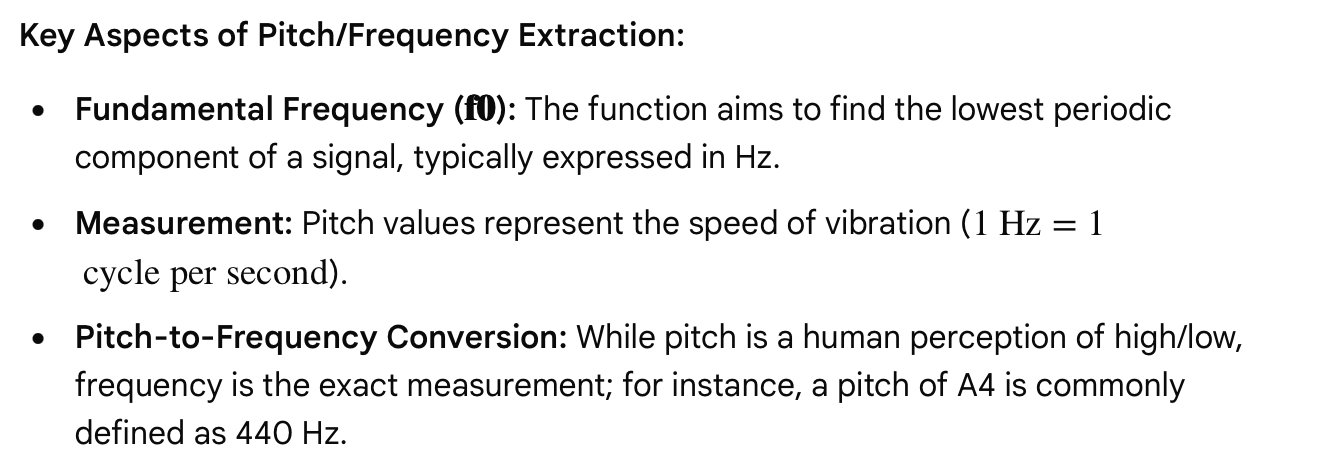

## Métricas de Intensidad (Volumen)

* Intensidad media: Volumen promedio de la señal
* Intensidad máxima/mínima: Valores extremos



In [ ]:
## Se llama al método to_intensity
## Minimun=define el valor más bajo esperado de pitch
## Time=define el tiempo entre frames a 1 milisegundo

intensity = sound.to_intensity(minimum_pitch=100.0, time_step=0.001, subtract_mean=True)

In [ ]:
## Extrae la intensidad máxima
max_intensity = np.max(intensity.values)

## Extrae la intensidad mínima
min_intensity = np.min(intensity.values[intensity.values > 0])

## Promedio de los valores intensidad
mean_intensity = intensity.get_average()

## Desviación estándar de los valores de intensidad
std_intensity = np.std(intensity.values[intensity.values > 0])

print(f"Intensidad Media: {mean_intensity:.2f} dB")
print(f"Intensidad Máxima: {max_intensity:.2f} dB")
print(f"Intensidad Mínima: {min_intensity:.2f} dB")
print(f"Desviación Estándar: {std_intensity:.2f} dB")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame for the intensity metrics
data_for_plot = pd.DataFrame({
    'Metric': ['Max Intensity', 'Min Intensity', 'Mean Intensity'],
    'Value': [max_intensity, min_intensity, mean_intensity]
})

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data_for_plot,
    x='Metric',
    y='Value',
    hue='Metric', # Differentiate points by metric name
    s=200,        # Size of the markers
    marker='o'    # Marker style
)

plt.title('Intensidad')
plt.ylabel('Valores (dB)')
plt.grid(True, linestyle='--')
plt.legend(title='')
plt.tight_layout()
plt.savefig('wav1-intensidad.png')
plt.show()

## Características Espectrales

* Formantes: Frecuencias de resonancia del tracto vocal
* Espectrogramas: Visualización de la energía de la señal en el tiempo y frecuencia
* MFCC (Mel-frequency cepstral coefficients): Coeficientes utilizados comúnmente en el reconocimiento de voz

In [ ]:
# Extraer Formantes
## Formant_burg es el método para extraer los formantes
## Time_step = cada 1 ms
## Maximum_formant = hz para voces femeninas (5000 para masculinas)
## Window = frames de 25 ms

formants = sound.to_formant_burg(time_step=0.01, max_number_of_formants=5, maximum_formant=5500, window_length=0.025)

f1 = formants.get_value_at_time(1, 0.5) # 0.5 segundo en el que se toma la medida
f2 = formants.get_value_at_time(2, 0.5)



print(f"F1: {f1}, F2: {f2}")


In [ ]:
## Extraer la F0

mean_f0 = pitch.selected_array['frequency']
mean_f0 = np.mean(mean_f0[mean_f0 > 0])

## Extraer la F0 a lo largo del tiempo
pitch_values = pitch.selected_array['frequency']
time_values = pitch.xs()

print(f"Frecuencia fundamental promedio: {mean_f0:.2f} Hz")


In [ ]:
##Graficar la F0

plt.figure(figsize=(10, 4))
plt.plot(pitch.xs(), pitch_values, 'v', markersize=2, color='blue')
plt.ylabel("F0 [Hz]")
plt.xlabel("Tiempo [s]")
plt.title("F0")
plt.savefig('wav1-f0.png')
plt.show()

In [ ]:
## Espectrograma

spectrogram = sound.to_spectrogram(window_length=0.005, maximum_frequency=5000)


X = spectrogram.x_grid()
Y = spectrogram.y_grid()
sg_db = 10 * np.log10(spectrogram.values) # Convertir a dB

# Graficar
plt.figure(figsize=(10, 5))
plt.pcolormesh(X, Y, sg_db, cmap='afmhot', shading='auto')
plt.ylim([0, spectrogram.ymin]) # Frecuencia máxima
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.colorbar(label="Intensidad [dB]")
plt.title("Espectrograma - Parselmouth")
plt.savefig('wav1-espectrograma.png')
plt.show()

In [ ]:
## Guardar los resultados en archivo de salida

with open('wav1-results.txt', 'w') as f:
  f.write(f'Resumen: {info}')
  f.write('\n')
  f.write(f"Tono Medio: {mean_pitch} Hz")
  f.write('\n')
  f.write(f"Tono Mínimo: {min_pitch} Hz")
  f.write('\n')
  f.write(f"Tono Máximo: {max_pitch} Hz")
  f.write('\n')
  f.write(f"Intensidad Media: {mean_intensity:.2f} dB")
  f.write('\n')
  f.write(f"Intensidad Máxima: {max_intensity:.2f} dB")
  f.write('\n')
  f.write(f"Intensidad Mínima: {min_intensity:.2f} dB")
  f.write('\n')
  f.write(f"Desviación Estándar: {std_intensity:.2f} dB")
  f.write('\n')
  f.write(f"F1: {f1}, F2: {f2}")
  f.write('\n')
  f.write(f"Frecuencia fundamental promedio: {mean_f0:.2f} Hz")
  f.write('\n')

In [ ]:
## Convertir en DF

features = {
    'Tono Medio': [mean_pitch],
    'Tono Mínimo': [min_pitch],
    'Tono Máximo': [max_pitch],
    'Intensidad Media': [mean_intensity],
    'Intensidad Máxima': [max_intensity],
    'Intensidad Mínima': [min_intensity],
    'Desviación Estándar': [std_intensity],
    'F1': [f1],
    'F2': [f2],
    'Frecuencia fundamental promedio': [mean_f0]
}

df = pd.DataFrame(features)

In [ ]:
## Guardar salida del DF como CSV

df_output = df.to_csv('wav1-results.csv', index=False)